# Face Mask Detection using CNN

## Objective:
 To classify whether a person is wearing a mask or not using deep learning.

In [1]:
!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print(path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
/kaggle/input/face-mask-dataset


In [4]:
path = path + '/data'

In [5]:
import os
print(os.listdir(path))

['without_mask', 'with_mask']


In [6]:
train_data = datagen.flow_from_directory(
    path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [9]:
model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
  1/189 ━━━━━━━━━━━━━━━━━━━━ 18:43 6s/step - accuracy: 0.4375 - loss: 0.7086

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 72s 352ms/step - accuracy: 0.8365 - loss: 0.4025 - val_accuracy: 0.9026 - val_loss: 0.2617
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - accuracy: 0.9067 - loss: 0.2369 - val_accuracy: 0.9132 - val_loss: 0.2271
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.9310 - loss: 0.1807 - val_accuracy: 0.9132 - val_loss: 0.2505
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.9472 - loss: 0.1374 - val_accuracy: 0.9325 - val_loss: 0.1912
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.9598 - loss: 0.1053 - val_accuracy: 0.9225 - val_loss: 0.2546


In [10]:
loss, acc = model.evaluate(val_data)
print("Accuracy:", acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9225 - loss: 0.2546
Accuracy: 0.9225165843963623


In [16]:
from google.colab import files
uploaded = files.upload()

Saving without_mask_92.jpg to without_mask_92.jpg


In [17]:
import os
print(os.listdir())

['.config', 'without_mask_94.jpg', 'without_mask_92.jpg', 'sample_data']


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
❌ Without Mask


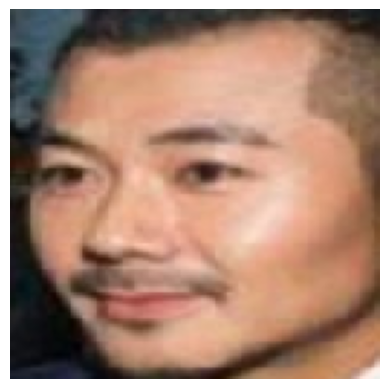

In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 👇 PUT YOUR FILE NAME HERE EXACTLY
img_path = 'without_mask_94.jpg'

img = image.load_img(img_path, target_size=(128,128))
plt.imshow(img)
plt.axis('off')

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("❌ Without Mask")
else:
    print("😷 With Mask")

In [19]:
model.save("face_mask_model.h5")